In [ ]:
from google.colab import files
uploaded=files.upload()

Saving ai_job_dataset.csv to ai_job_dataset.csv


In [ ]:
import io
import pandas as pd
df=pd.read_csv("ai_job_dataset.csv")

## **Importing necessary libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from PIL import Image
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest,f_regression
from sklearn.ensemble import ExtraTreesRegressor
import warnings
warnings.filterwarnings("ignore")

## **Data Overview**

In [ ]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [ ]:
print("\nshape")
print(df.shape)
print("\ndata information")
print(df.info())
print("\ndescription")
print(df.describe().T)
print("\ncolumn")
print(df.columns)
print('No. of duplicated rows: ' , len(df[df.duplicated()]))
print("No. of Missing values",df.isnull().sum().sum())
print("\nUnique values")
print(df.nunique())


shape
(15000, 19)

data information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  p



*  We can observe that there are no missing values and duplicate values in this dataset,and it's an advantage for us.



## **Feature Engineering**

In [ ]:
columns_to_drop = ['job_id','salary_currency']
df = df.drop(columns=columns_to_drop)

In [ ]:
## Total no. of skills required
df['total_required_skills'] = df['required_skills'].apply(lambda x: len([skill.strip() for skill in x.split(',') if skill.strip()]))

In [ ]:
df.head()

,job_title,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,total_required_skills
0,AI Research Scientist,90376,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics,5
1,AI Software Engineer,61895,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,5
2,AI Specialist,152626,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech,5
3,NLP Engineer,80215,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems,4
4,AI Consultant,54624,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics,4


In [ ]:
df['salary'] = np.log1p(df['salary_usd'])

In [ ]:
df["posting_date"] = pd.to_datetime(df["posting_date"])

## **EDA**

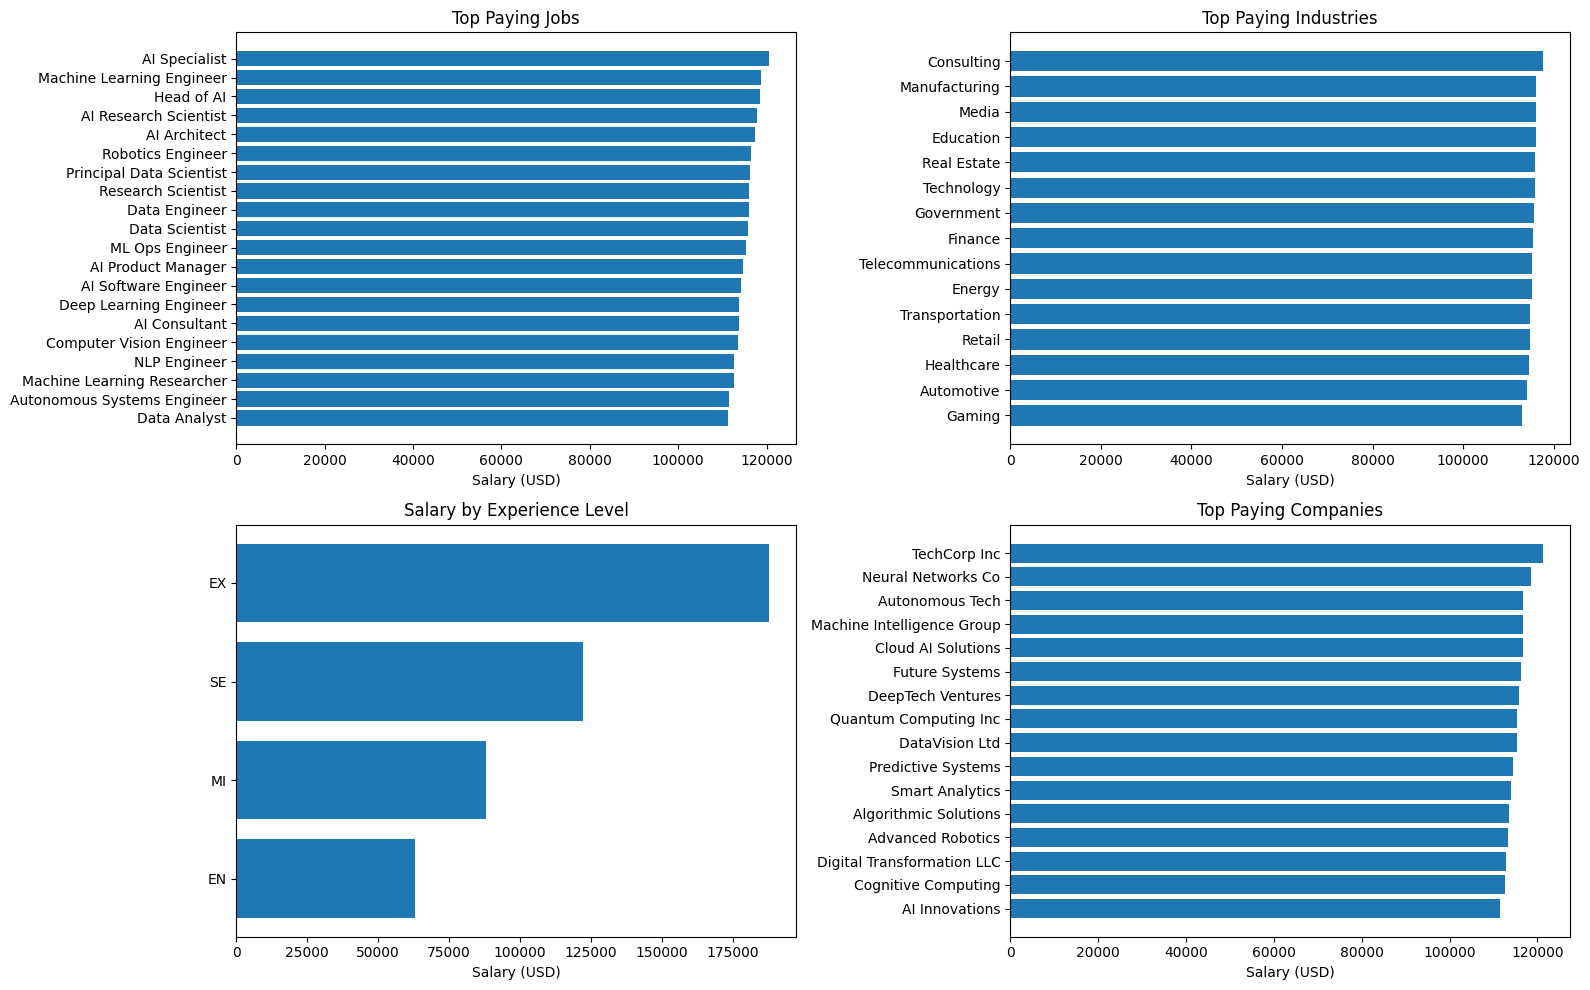

In [ ]:
## Top Paying
top_jobs = df.groupby("job_title")["salary_usd"].mean().sort_values(ascending=False)
top_industries = df.groupby("industry")["salary_usd"].mean().sort_values(ascending=False)
top_experience = df.groupby("experience_level")["salary_usd"].mean().sort_values(ascending=False)
top_companies = df.groupby("company_name")["salary_usd"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top Paying Jobs
axes[0, 0].barh(top_jobs.index[::-1], top_jobs.values[::-1])
axes[0, 0].set_title("Top Paying Jobs")
axes[0, 0].set_xlabel("Salary (USD)")


# Top Paying Industries
axes[0, 1].barh(top_industries.index[::-1], top_industries.values[::-1])
axes[0, 1].set_title("Top Paying Industries")
axes[0, 1].set_xlabel("Salary (USD)")


# Salary by Experience Level
axes[1, 0].barh(top_experience.index[::-1], top_experience.values[::-1])
axes[1, 0].set_title("Salary by Experience Level")
axes[1, 0].set_xlabel("Salary (USD)")


# Top Paying Companies
axes[1, 1].barh(top_companies.index[::-1], top_companies.values[::-1])
axes[1, 1].set_title("Top Paying Companies")
axes[1, 1].set_xlabel("Salary (USD)")



plt.tight_layout()
plt.show()


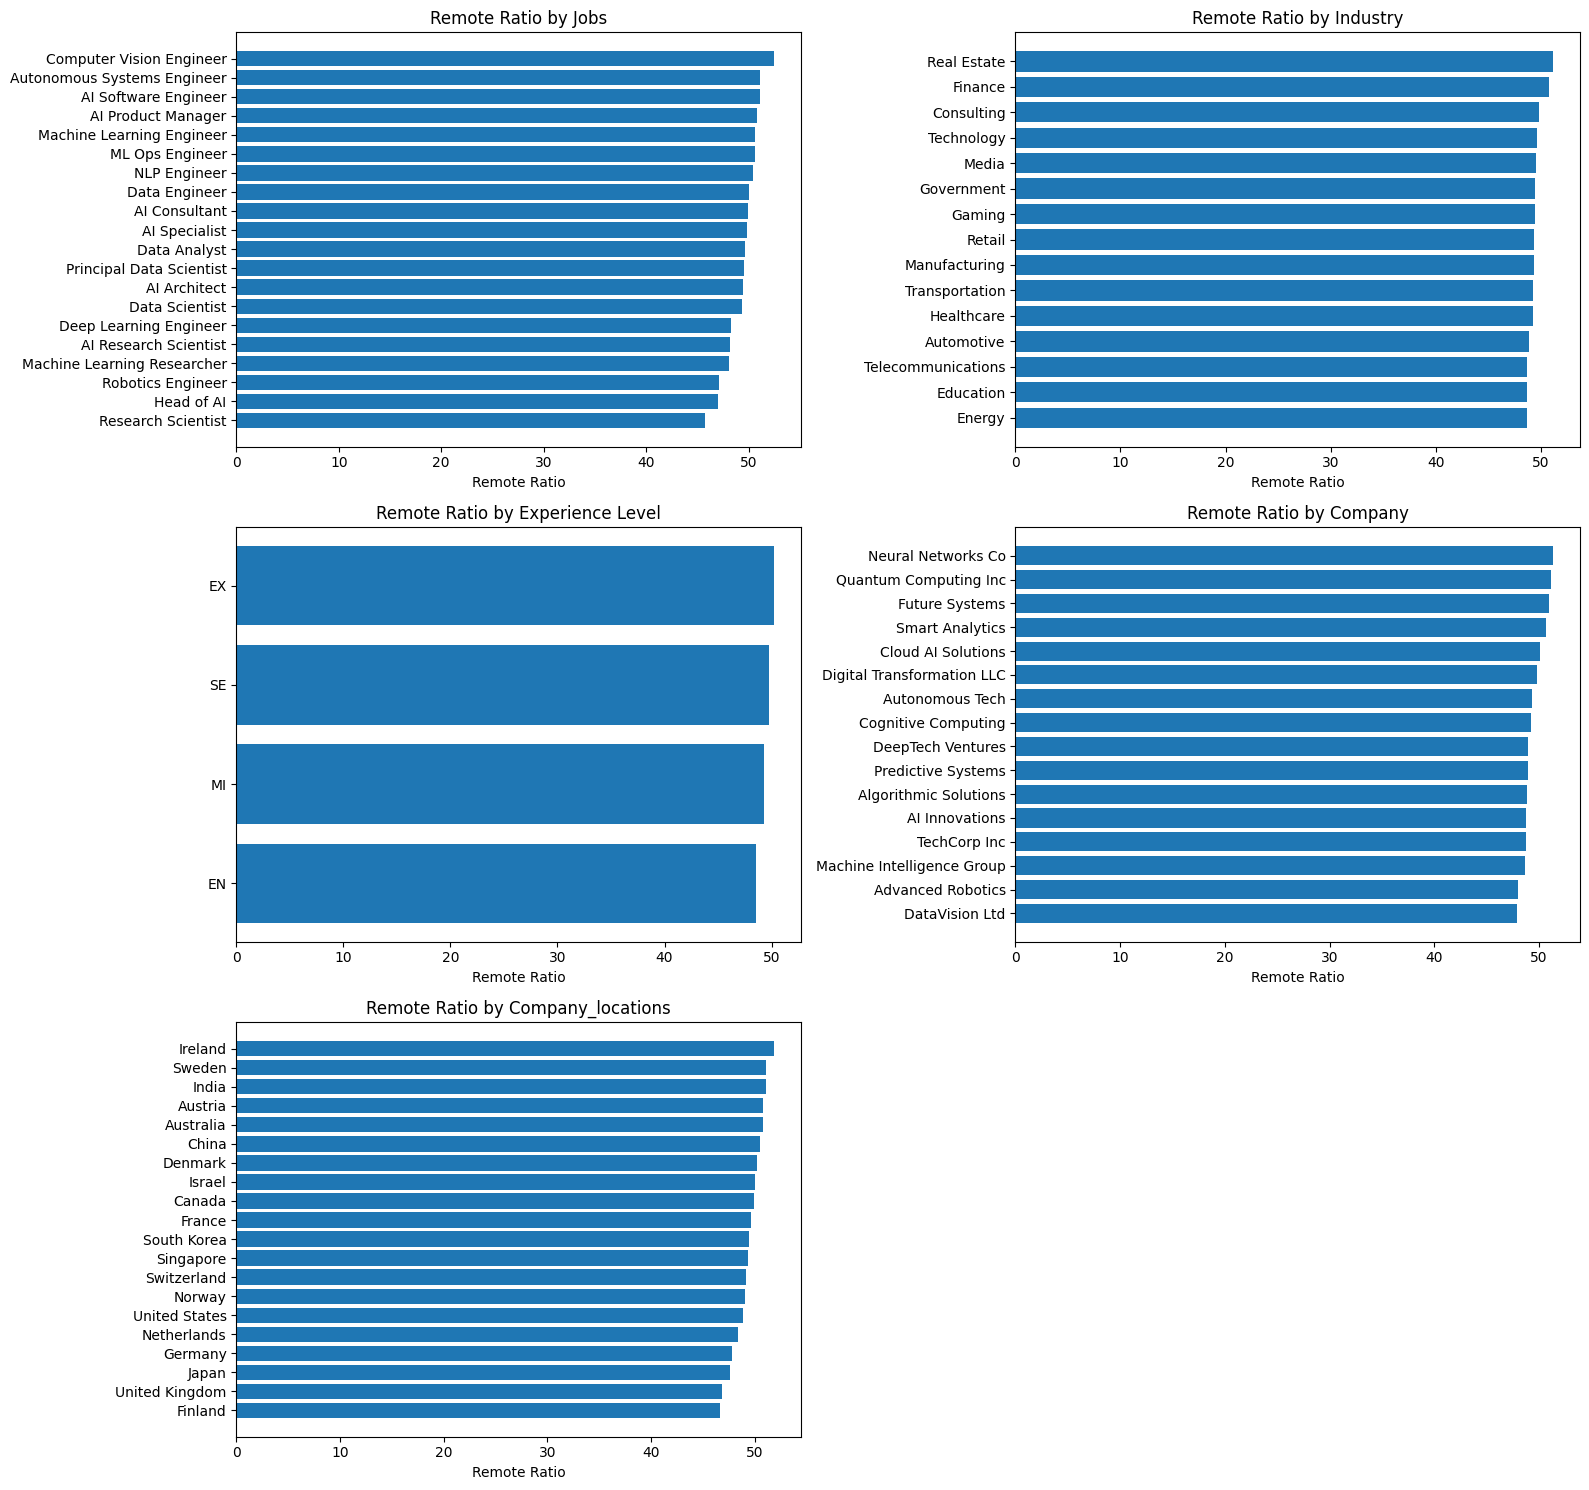

In [ ]:
## Remote work trends
remote_jobs = df.groupby("job_title")["remote_ratio"].mean().sort_values(ascending=False)
remote_industries = df.groupby("industry")["remote_ratio"].mean().sort_values(ascending=False)
remote_experience = df.groupby("experience_level")["remote_ratio"].mean().sort_values(ascending=False)
remote_companies = df.groupby("company_name")["remote_ratio"].mean().sort_values(ascending=False)
remote_locations = df.groupby("company_location")["remote_ratio"].mean().sort_values(ascending=False)

# Create a 3x2 grid for the subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 15)) # Increased figsize for more space

# Flatten the axes array to easily iterate through subplots
axes = axes.flatten()

# Plot Remote Ratio by Jobs
axes[0].barh(remote_jobs.index[::-1], remote_jobs.values[::-1])
axes[0].set_title("Remote Ratio by Jobs")
axes[0].set_xlabel("Remote Ratio")

# Plot Remote Ratio by Industry
axes[1].barh(remote_industries.index[::-1], remote_industries.values[::-1])
axes[1].set_title("Remote Ratio by Industry")
axes[1].set_xlabel("Remote Ratio")

# Plot Remote Ratio by Experience Level
axes[2].barh(remote_experience.index[::-1], remote_experience.values[::-1])
axes[2].set_title("Remote Ratio by Experience Level")
axes[2].set_xlabel("Remote Ratio")

# Plot Remote Ratio by Company
axes[3].barh(remote_companies.index[::-1], remote_companies.values[::-1])
axes[3].set_title("Remote Ratio by Company")
axes[3].set_xlabel("Remote Ratio")

# Plot Remote Ratio by Company Locations
axes[4].barh(remote_locations.index[::-1], remote_locations.values[::-1])
axes[4].set_title("Remote Ratio by Company_locations")
axes[4].set_xlabel("Remote Ratio")

# Hide the last unused subplot in the 3x2 grid
fig.delaxes(axes[5])


plt.tight_layout()
plt.show()


Top skills
Python        4450
SQL           3407
TensorFlow    3022
Kubernetes    3009
Scala         2794
PyTorch       2777
Linux         2705
Git           2631
Java          2578
GCP           2442
Name: count, dtype: int64

Top demanding jobs
0       AI Research Scientist
1        AI Software Engineer
2               AI Specialist
3                NLP Engineer
4               AI Consultant
5                AI Architect
6    Principal Data Scientist
7                NLP Engineer
8                Data Analyst
9        AI Software Engineer
Name: job_title, dtype: object


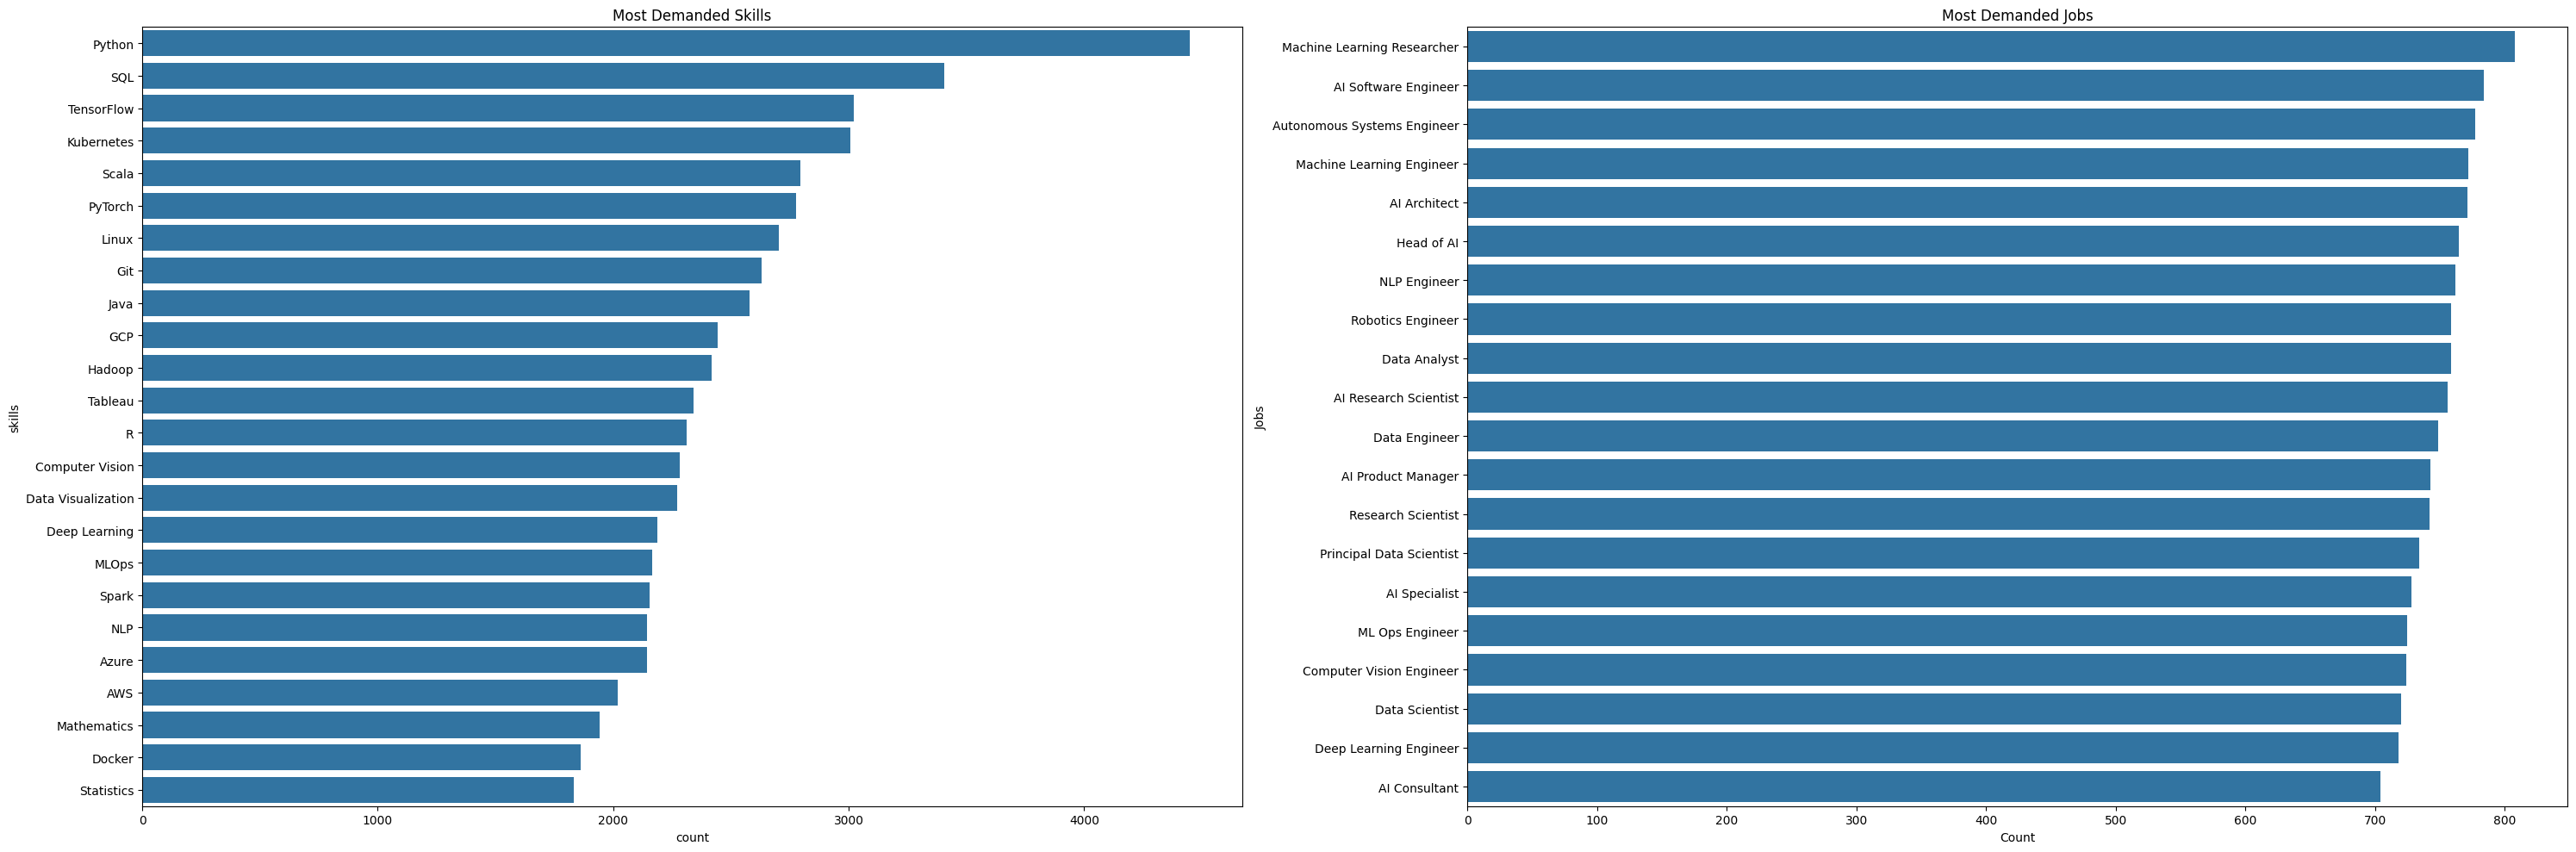

In [ ]:
# Market demand
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(30,10))

all_skills_list = [skill.strip() for skills_str in df['required_skills'].dropna() for skill in skills_str.split(',')]

skills_series = pd.Series(all_skills_list)
top_skills = skills_series.value_counts()
print("\nTop skills")
print(top_skills.head(10))


sns.countplot(y='skills', data=pd.DataFrame({'skills': skills_series}), order=skills_series.value_counts().index,ax=ax1)
ax1.set_title('Most Demanded Skills')
plt.xlabel('Count')
plt.ylabel('All_skills')
plt.tight_layout()

most_demand_jobs = df['job_title'].value_counts()
print("\nTop demanding jobs")
print(df['job_title'].head(10))

sns.countplot(y='job_title', data=df, order=df['job_title'].value_counts().index,ax=ax2)
ax2.set_title('Most Demanded Jobs')
plt.xlabel('Count')
plt.ylabel('Jobs')
plt.tight_layout()
plt.show()

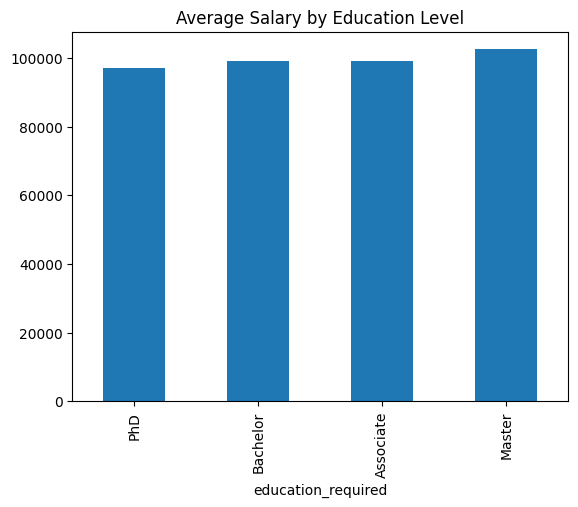

In [ ]:
## Average salary by education level
df.groupby("education_required")["salary_usd"].median().sort_values().plot(kind='bar')
plt.title('Average Salary by Education Level')
plt.show()

## **Feature Selection**

In [ ]:
columns_to_drop_before_encoding = [
    'required_skills',
    'posting_date',
    'application_deadline',
    'salary_usd'
]

columns_to_drop_before_encoding = [col for col in columns_to_drop_before_encoding if col in df.columns]
df_cleaned_for_encoding = df.drop(columns=columns_to_drop_before_encoding)

print(f"Columns dropped from features for encoding: {columns_to_drop_before_encoding}")
print("DataFrame shape after initial cleaning for encoding:", df_cleaned_for_encoding.shape)


ordinal_features = {
    'experience_level': ['EN', 'MI', 'SE', 'EX'],
    'education_required': ['Associate', 'Bachelor', 'Master', 'PhD'],
    'company_size': ['S', 'M', 'L']}

ordinal_feature_names_list = list(ordinal_features.keys())

nominal_features = [
    'job_title',
    'employment_type',
    'company_location',
    'employee_residence',
    'industry',
    'company_name',
    'remote_ratio'
]
if 'remote_ratio' in df_cleaned_for_encoding.columns:
    df_cleaned_for_encoding['remote_ratio'] = df_cleaned_for_encoding['remote_ratio'].astype(str)


numerical_features = [
    'years_experience',
    'job_description_length',
    'benefits_score',
    'num_required_skills',
]

numerical_features = [col for col in numerical_features if col in df_cleaned_for_encoding.columns]
nominal_features = [col for col in nominal_features if col in df_cleaned_for_encoding.columns]
ordinal_feature_names_list = [col for col in ordinal_feature_names_list if col in df_cleaned_for_encoding.columns]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_features),
        ('ord', OrdinalEncoder(categories=[ordinal_features[col] for col in ordinal_feature_names_list],
                               handle_unknown='use_encoded_value', unknown_value=-1),
         ordinal_feature_names_list),
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features) # sparse_output=False for dense output
    ],
    remainder='drop'
)
X = df_cleaned_for_encoding
y = df['salary']


pipeline = Pipeline(steps=[('preprocessor', preprocessor)])


X_processed_array = pipeline.fit_transform(X)
numerical_output_features = numerical_features
ordinal_output_features = ordinal_feature_names_list

ohe_output_features = pipeline.named_steps['preprocessor'].named_transformers_['nom'].get_feature_names_out(nominal_features)
all_processed_feature_names = numerical_output_features + ordinal_output_features + list(ohe_output_features)

X_processed = pd.DataFrame(X_processed_array, columns=all_processed_feature_names)
print(X_processed.columns.tolist())

Columns dropped from features for encoding: ['required_skills', 'posting_date', 'application_deadline', 'salary_usd']
DataFrame shape after initial cleaning for encoding: (15000, 15)
['years_experience', 'job_description_length', 'benefits_score', 'experience_level', 'education_required', 'company_size', 'job_title_AI Architect', 'job_title_AI Consultant', 'job_title_AI Product Manager', 'job_title_AI Research Scientist', 'job_title_AI Software Engineer', 'job_title_AI Specialist', 'job_title_Autonomous Systems Engineer', 'job_title_Computer Vision Engineer', 'job_title_Data Analyst', 'job_title_Data Engineer', 'job_title_Data Scientist', 'job_title_Deep Learning Engineer', 'job_title_Head of AI', 'job_title_ML Ops Engineer', 'job_title_Machine Learning Engineer', 'job_title_Machine Learning Researcher', 'job_title_NLP Engineer', 'job_title_Principal Data Scientist', 'job_title_Research Scientist', 'job_title_Robotics Engineer', 'employment_type_CT', 'employment_type_FL', 'employment_t

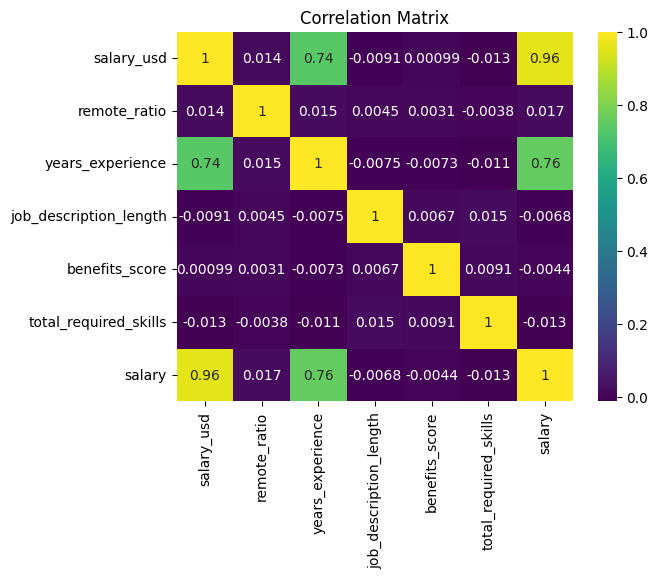

salary_usd                1.000000
salary                    0.957772
years_experience          0.737556
remote_ratio              0.013727
benefits_score            0.000985
job_description_length   -0.009092
total_required_skills    -0.012879
Name: salary_usd, dtype: float64


In [ ]:
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='viridis')
plt.title("Correlation Matrix")
plt.show()

print(correlation['salary_usd'].sort_values(ascending=False))


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)
selector_f = SelectKBest(f_regression, k=50)
selector_f.fit(X_train, y_train)
f_scores_df = pd.DataFrame({'Feature': X_train.columns, 'F_Score': selector_f.scores_, 'P_Value': selector_f.pvalues_})
f_scores_df = f_scores_df.sort_values(by='F_Score', ascending=False)
print("\nTop 20 Features by F-Score:")
print(f_scores_df.head(20))


Top 20 Features by F-Score:
                           Feature       F_Score        P_Value
3                 experience_level  22040.549603   0.000000e+00
0                 years_experience  15769.356425   0.000000e+00
5                     company_size    561.258158  2.664297e-121
47    company_location_Switzerland    476.234016  1.436462e-103
34        company_location_Denmark    425.214395   7.220445e-93
43         company_location_Norway    294.990298   2.450772e-65
67  employee_residence_Switzerland    231.538104   8.375959e-52
31        company_location_Austria    216.168024   1.636768e-48
33          company_location_China    210.728112   2.398769e-47
38          company_location_India    207.215048   1.359362e-46
39        company_location_Ireland    186.203292   4.415649e-42
45    company_location_South Korea    184.104942   1.247724e-41
54      employee_residence_Denmark    182.655236   2.557712e-41
49  company_location_United States    175.968813   7.019420e-40
41         

In [ ]:
rf_model_for_importance = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_for_importance.fit(X_train, y_train)
feature_importances_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model_for_importance.feature_importances_})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)
print("\nTop 20 Features by RandomForest Importance:")
print(feature_importances_df.head(20))

N_FEATURES_TO_SELECT = 60
selected_features = feature_importances_df['Feature'].head(N_FEATURES_TO_SELECT).tolist()
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]
print(f"\nSelected {N_FEATURES_TO_SELECT} features based on RandomForest importance.")
print("Shape of X_train_selected:", X_train_selected.shape)
print("Shape of X_test_selected:", X_test_selected.shape)
print("First 10 selected feature names:", selected_features[:10])


Top 20 Features by RandomForest Importance:
                            Feature  Importance
0                  years_experience    0.407284
3                  experience_level    0.246729
5                      company_size    0.045397
47     company_location_Switzerland    0.042472
34         company_location_Denmark    0.030910
43          company_location_Norway    0.029588
49   company_location_United States    0.020958
48  company_location_United Kingdom    0.012335
1            job_description_length    0.011952
42     company_location_Netherlands    0.011854
44       company_location_Singapore    0.011838
37         company_location_Germany    0.011762
46          company_location_Sweden    0.011575
36          company_location_France    0.011463
32          company_location_Canada    0.011429
30       company_location_Australia    0.011320
2                    benefits_score    0.010138
4                education_required    0.003397
45     company_location_South Korea    0.00

## **Model Evaluation**



*   **Linear Regression Model**
*  **Random Forest Regressor Model**
*   **XGBoost Regressor**



In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train_selected,y_train)
y_pred_log=linear_model.predict(X_test_selected)

In [ ]:
mae = mean_absolute_error(y_test, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2 = r2_score(y_test, y_pred_log)

In [ ]:
print("Model Evaluation Metrics(Linear Regression Scores):")
print(f"MAE  (Mean Absolute Error):      {mae:.2f}")
print(f"RMSE (Root Mean Squared Error):  {rmse:.2f}")
print(f"R²   (R-squared Score):          {r2:.4f}")

Model Evaluation Metrics(Linear Regression Scores):
MAE  (Mean Absolute Error):      0.12
RMSE (Root Mean Squared Error):  0.14
R²   (R-squared Score):          0.9183


In [ ]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1,
                                     max_depth=10, min_samples_leaf=5)
rf_model.fit(X_train_selected, y_train)
y_pred =rf_model.predict(X_test_selected)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [ ]:
print("Model Evaluation Metrics ((Random Forest Regression Scores)):")
print(f"MAE  (Mean Absolute Error):      {mae:.2f}")
print(f"RMSE (Root Mean Squared Error):  {rmse:.2f}")
print(f"R²   (R-squared Score):          {r2:.4f}")

Model Evaluation Metrics ((Random Forest Regression Scores)):
MAE  (Mean Absolute Error):      0.15
RMSE (Root Mean Squared Error):  0.19
R²   (R-squared Score):          0.8592


In [ ]:
xgb_model = XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1,
                                     max_depth=10, min_samples_leaf=5)
xgb_model.fit(X_train_selected, y_train)
y_pred_xgb=xgb_model.predict(X_test_selected)

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

In [ ]:
print("Model Evaluation Metrics ((XgBoost Regressor Scores)):")
print(f"MAE  (Mean Absolute Error):      {mae:.2f}")
print(f"RMSE (Root Mean Squared Error):  {rmse:.2f}")
print(f"R²   (R-squared Score):          {r2:.4f}")

Model Evaluation Metrics ((XgBoost Regressor Scores)):
MAE  (Mean Absolute Error):      0.13
RMSE (Root Mean Squared Error):  0.16
R²   (R-squared Score):          0.8969


We observe that linear odel is given the best MSE value ,we can consider this is the best fit model for this dataset

In [ ]:
##Submission
X_test_selected_for_submission = X_test[selected_features]

test_pred = linear_model.predict(X_test_selected_for_submission)
submission = pd.DataFrame(index=X_test_selected_for_submission.index)

test_pred = np.expm1(test_pred) #
submission['salary_usd'] = test_pred

submission.to_csv("submission.csv", index=False)

print("CSV file with predicted values has been created successfully.")
print(submission.head())

CSV file with predicted values has been created successfully.
          salary_usd
11499  153037.927071
6475   167044.802172
13167  139843.481762
862    168893.706408
5970    68473.150891
